# 09. Optimizare neliniara - Load shifting (Consum USA)

**Etapa III: Optimizare neliniara (suport decizional prescriptiv) - a doua problema**

**Scop:** reducerea costului energiei prin **mutarea consumului flexibil** in orele mai ieftine. Spre deosebire de baterie (care stocheaza energie), aici mutam in timp o parte din cerere (de exemplu, incarcarea masinilor electrice, pomparea apei, procese industriale amanabile), fara sa schimbam energia totala consumata - doar momentul.

Folosim consumul prognozat al regiunii PJM (Etapa II) si un tarif **time-of-use** (pret diferentiat pe ore). In productie, cererea ar veni de la modelul XGBoost de consum.

## Setup

In [1]:
import sys, time
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.optimization.optimizer import (
    LoadShiftConfig, time_of_use_tariff, load_shifting_problem,
    solve_load_shifting, load_cost,
)
from src.utils.plotting import setup_style, PALETA
setup_style()
warnings.filterwarnings("ignore")
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Setup OK.")

Setup OK.


## 1. Problema si tariful time-of-use

### Ideea prescriptiva
Daca energia e mai scumpa seara (varf de cerere) si mai ieftina noaptea, putem muta consumul flexibil din orele scumpe in cele ieftine si plati mai putin pentru aceeasi energie. Constrangerea cheie: **energia totala se pastreaza** - nu consumam mai putin, doar in alt moment.

### Variabile, obiectiv, constrangeri
- **Variabile**: `s_t` = ajustarea consumului la ora t (pozitiv = aducem consum aici, negativ = mutam de aici).
- **Obiectiv (minimizat)**: factura = `sum(tarif_t x (cerere_t + s_t))` plus o **penalizare de confort** `lambda x sum(s_t^2)` care descurajeaza mutarile extreme (nu putem amana la nesfarsit toate aparatele). Termenul patratic face problema **neliniara**.
- **Constrangeri**: `|s_t| <= 20% x cerere_t` (doar partea flexibila) si `sum(s_t) = 0` (energie conservata).

### Tariful folosit
Off-peak (noaptea, 22-7): 40 EUR/MWh. Mediu (ziua, 7-17): 70. Varf (seara, 17-22): 120.

In [2]:
hours_demo = np.arange(24)
tariff_demo = time_of_use_tariff(hours_demo)
for h in [3, 10, 19]:
    print(f"  Ora {h:2d}: {time_of_use_tariff(np.array([h]))[0]:.0f} EUR/MWh")

  Ora  3: 40 EUR/MWh
  Ora 10: 70 EUR/MWh
  Ora 19: 120 EUR/MWh


## 2. Incarcarea cererii prognozate

Folosim ultimele 48 de ore (2 zile) din seria de consum PJM. Profilul tipic - varf seara, minim noaptea - este exact ce permite mutarea consumului.

In [3]:
df = pd.read_parquet(PROJECT_ROOT / "data" / "processed" / "consum_usa_features.parquet")
WINDOW = 48
demand = df["PJME_MW"].iloc[-WINDOW:].values.astype(float)
hours = df.index[-WINDOW:].hour.values
tariff = time_of_use_tariff(hours)
idx = df.index[-WINDOW:]
print(f"Fereastra: {idx[0]} -> {idx[-1]} ({WINDOW} ore)")
print(f"Cerere: min={demand.min():.0f}, medie={demand.mean():.0f}, max={demand.max():.0f} MW")

Fereastra: 2018-08-01 01:00:00 -> 2018-08-03 00:00:00 (48 ore)
Cerere: min=28249, medie=39462, max=49308 MW


## 3. Rezolvarea problemei (SLSQP)

In [4]:
cfg = LoadShiftConfig(flex_fraction=0.2, lambda_comfort=0.001)
t = time.time()
out = solve_load_shifting(demand, tariff, cfg)
res = out["result"]; s = out["s"]
print(f"Optimizare in {time.time()-t:.2f}s | convergenta: {res.success} | iteratii: {res.n_iter}")
print(f"\nCost baseline (fara mutare): {out['baseline_cost']:,.0f} EUR")
print(f"Cost optimizat:              {out['optimized_cost']:,.0f} EUR")
print(f"ECONOMIE: {out['savings']:,.0f} EUR ({100*out['savings']/out['baseline_cost']:.2f}%)")
print(f"\nVerificare: sum(s) = {s.sum():.2f} (trebuie ~0, energie conservata)")
print(f"Mutare maxima: {np.abs(s).max():.0f} MW (limita 20% din cerere)")

Optimizare in 0.06s | convergenta: True | iteratii: 38

Cost baseline (fara mutare): 137,870,580 EUR
Cost optimizat:              131,331,301 EUR
ECONOMIE: 6,539,279 EUR (4.74%)

Verificare: sum(s) = 0.00 (trebuie ~0, energie conservata)
Mutare maxima: 9862 MW (limita 20% din cerere)


## 4. Vizualizare: cererea originala vs optimizata

Bara de fundal arata tariful (rosu = varf scump, albastru = off-peak ieftin). Linia neagra e cererea originala, cea verde - cererea dupa optimizare. Observam cum consumul scade in orele de varf (scumpe) si creste in cele ieftine, aplatizand profilul.

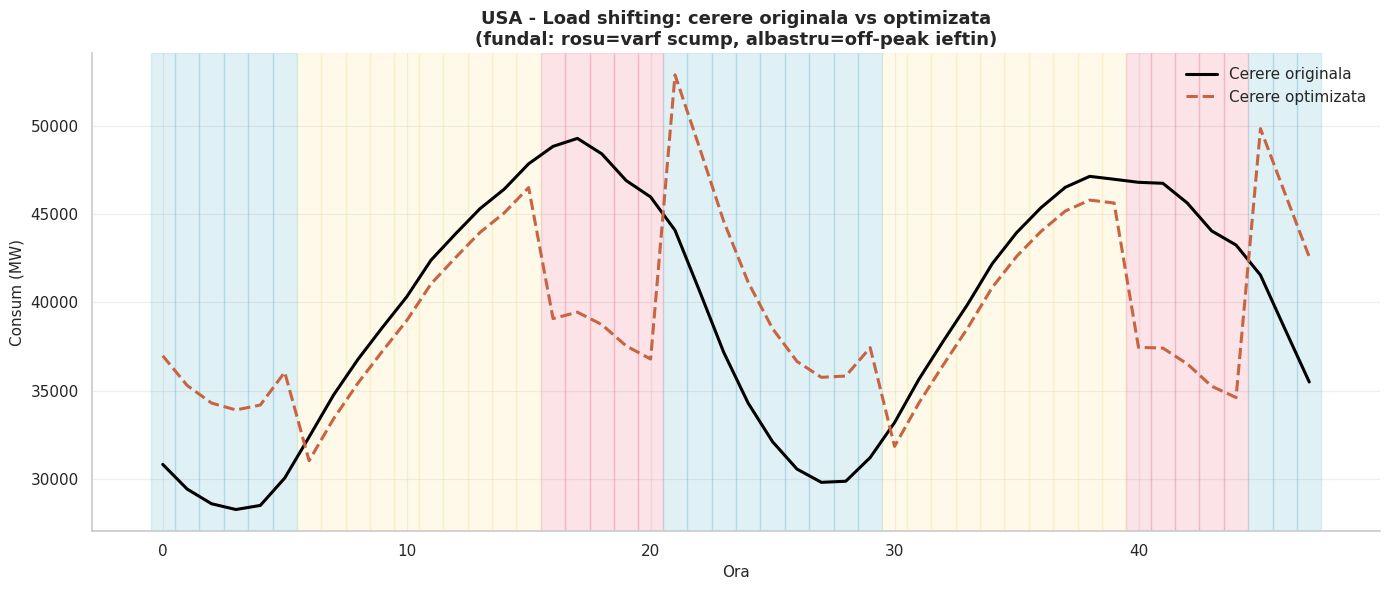

Figura salvata: reports/figures/fig_9_1_load_shifting.png


In [5]:
demand_opt = demand + s
fig, ax = plt.subplots(figsize=(14, 6))
# benzi tarif in fundal
for i, h in enumerate(hours):
    tr = tariff[i]
    color = "#E11D48" if tr >= 120 else ("#0891B2" if tr <= 40 else "#FCD34D")
    ax.axvspan(i-0.5, i+0.5, color=color, alpha=0.12)
ax.plot(range(WINDOW), demand, color="black", lw=2.2, label="Cerere originala")
ax.plot(range(WINDOW), demand_opt, color=PALETA["secondary"], lw=2.2, ls="--", label="Cerere optimizata")
ax.set_xlabel("Ora"); ax.set_ylabel("Consum (MW)")
ax.set_title("USA - Load shifting: cerere originala vs optimizata\n(fundal: rosu=varf scump, albastru=off-peak ieftin)")
ax.legend(loc="upper right"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_9_1_load_shifting.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_9_1_load_shifting.png")

## 5. Analiza de sensibilitate: cat flexibilitate, atata economie

Cu cat o parte mai mare din consum e flexibila, cu atat putem muta mai mult si economisi mai mult. Verificam cum creste economia cu fractiunea flexibila.

 flex_fraction  economie_EUR  economie_%
          0.05     1958364.0        1.42
          0.10     3701032.0        2.68
          0.20     6539279.0        4.74
          0.30     8514791.0        6.18
          0.50    10225724.0        7.42


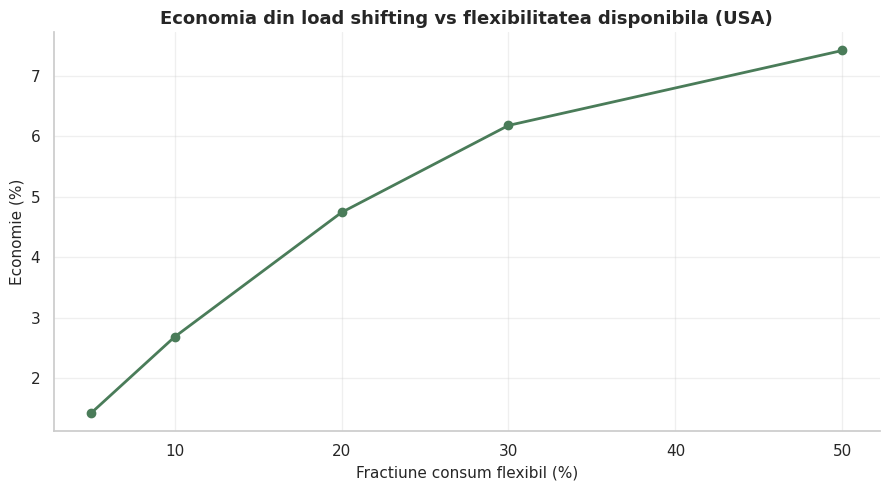

Figura salvata: reports/figures/fig_9_2_sensibilitate_flex.png


In [6]:
rows = []
for flex in [0.05, 0.1, 0.2, 0.3, 0.5]:
    o = solve_load_shifting(demand, tariff, LoadShiftConfig(flex_fraction=flex, lambda_comfort=cfg.lambda_comfort))
    rows.append({"flex_fraction": flex, "economie_EUR": round(o["savings"], 0),
                 "economie_%": round(100*o["savings"]/o["baseline_cost"], 2)})
sens = pd.DataFrame(rows)
print(sens.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sens["flex_fraction"]*100, sens["economie_%"], marker="o", color=PALETA["tertiary"], lw=2)
ax.set_xlabel("Fractiune consum flexibil (%)"); ax.set_ylabel("Economie (%)")
ax.set_title("Economia din load shifting vs flexibilitatea disponibila (USA)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_9_2_sensibilitate_flex.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figura salvata: reports/figures/fig_9_2_sensibilitate_flex.png")

## 6. Concluzii

A doua problema de optimizare confirma versatilitatea abordarii prescriptive: aceeasi unealta (optimizare neliniara cu SLSQP) rezolva o problema complet diferita de cea a bateriei. Aici, mutand doar partea flexibila a consumului in orele ieftine, reducem factura cu cateva procente fara sa consumam mai putina energie - doar reorganizand-o in timp. Economia creste cu flexibilitatea disponibila.

Impreuna, dispatch-ul bateriei (problema 1) si load shifting-ul (problema 2) arata cum platforma transforma predictiile in decizii operationale concrete pentru actori diferiti din sistemul energetic: un operator de stocare, respectiv un consumator mare cu sarcini flexibile.